In [ ]:
import numpy as np
from scipy.ndimage import distance_transform_edt

def signed_distance_transform(
    mask: np.ndarray, spacing: tuple[float, float, float] = (1.0, 1.0, 1.0)
) -> np.ndarray:
    """
    Compute the signed distance transform of a 3D binary mask.

    Parameters
    ----------
    mask : (Z, Y, X) array of bool
        True inside the region (e.g. brain), False outside.
    spacing : tuple of floats
        Voxel dimensions (dz, dy, dx) in millimetres.

    Returns
    -------
    sdt : (Z, Y, X) array of float32
        Signed distance at each voxel: positive inside the mask,
        negative outside, zero exactly on the boundary.
    """
    # distance inside: for voxels in mask, distance to nearest False
    inside_dist = distance_transform_edt(mask, sampling=spacing)
    # distance outside: for voxels not in mask, distance to nearest True
    outside_dist = distance_transform_edt(~mask, sampling=spacing)

    # allocate output
    sdt = inside_dist.astype(np.float32)
    # assign negative distances for background voxels
    sdt[~mask] = -outside_dist[~mask]

    return sdt

In [9]:
import SimpleITK as sitk

img  = sitk.ReadImage('/media/vzalevskyi/data/neonatal_bobsV1.0/sub-116845/ses-3mo/anat/sub-116845_ses-3mo_space-INFANTMNIacpc_desc-feta_dseg.nii.gz')
img = sitk.GetArrayFromImage(img)
num_labels = img.max() + 1
img1h = np.zeros((num_labels, *img.shape), dtype=bool)
for i in range(num_labels):
    img1h[i] = img == i
print(img1h.shape)

img1hSDT = np.zeros_like(img1h, dtype=np.float32)
for i in range(num_labels):
    img1hSDT[i] = signed_distance_transform(mask=img1h[i], spacing=(1.0, 1.0, 1.0))

(8, 182, 218, 182)


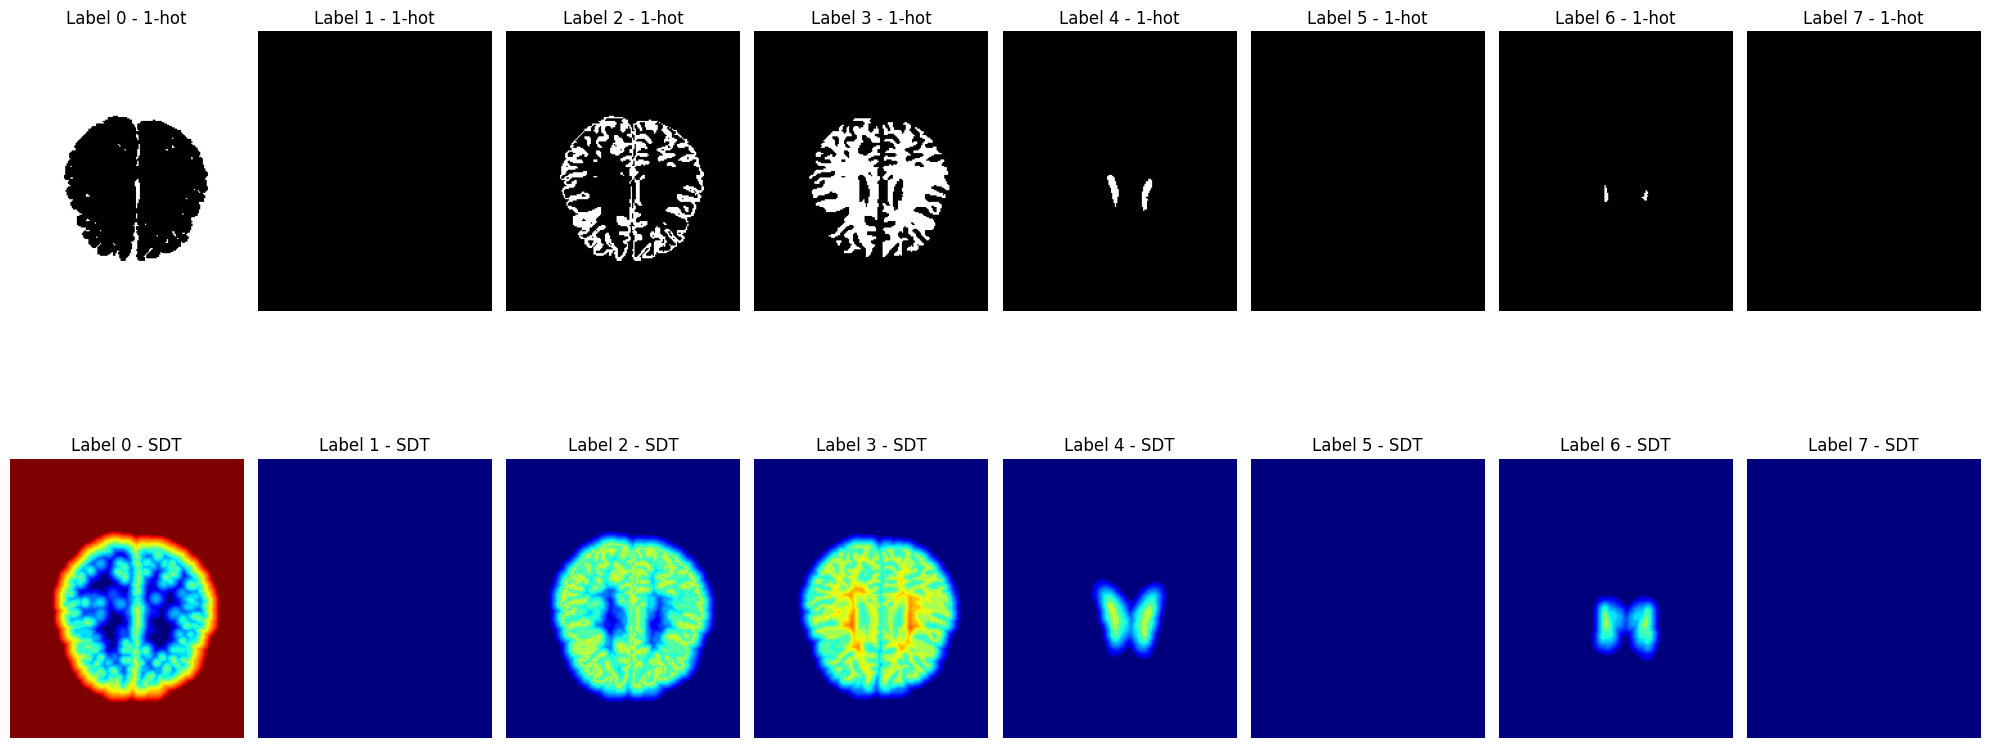

In [13]:
import matplotlib.pyplot as plt

# plot slices for each label in 2 rows (1 row 1h, 1 row SDT)
fig, axs = plt.subplots(2, num_labels, figsize=(20, 10))

for i in range(num_labels):
    axs[0, i].imshow(img1h[i, img1h.shape[1] // 2, :, :], cmap='gray')
    axs[0, i].set_title(f'Label {i} - 1-hot')
    axs[0, i].axis('off')

    axs[1, i].imshow(img1hSDT[i, img1hSDT.shape[1] // 2, :, :], cmap='jet', vmin=-10, vmax=10)
    axs[1, i].set_title(f'Label {i} - SDT')
    axs[1, i].axis('off')

plt.tight_layout()
plt.show()